In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

In [2]:
files = [
    "CRMLSSold202506.csv",
    "CRMLSSold202507.csv",
    "CRMLSSold202508.csv",
    "CRMLSSold202509.csv",
    "CRMLSSold202510.csv",
    "CRMLSSold202511.csv",
    "CRMLSSold202512.csv",
]

dfs = []

for fname in files:
    df_tmp = pd.read_csv(f"data_raw_original/{fname}")
    df_tmp["source_month"] = fname.replace("CRMLSSold", "").replace(".csv", "")
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
df

C:\Users\yhy_s\AppData\Local\Temp\ipykernel_39076\3652408873.py:14: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tmp = pd.read_csv(f"data_raw_original/{fname}")


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_month
0,SanDiego,SanDiego,NaN,False,NaN,NaN,False,5000.0,542181398,ops@downtowncondoguys.com,...,NaN,NaN,NaN,1.0,NaN,92101,0.0,NaN,NaN,202506
1,PacificWest,PacificWest,NaN,True,NaN,NaN,NaN,110000.0,540760713,nowjoanne@gmail.com,...,355936.0000,NaN,False,NaN,NaN,93550,0.0,355936.00,NaN,202506
2,SouthwestLosAngeles,SouthwestLosAngeles,NaN,True,NaN,NaN,NaN,1545000.0,525608302,Austin_Brown@pacificplayarealty.com,...,20212.0000,NaN,False,NaN,NaN,90008,NaN,20212.00,NaN,202506
3,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,False,889000.0,523319952,hutton@cbappteam.com,...,9600.0000,0.0,True,2.0,Rim of the World,92352,0.0,9600.00,NaN,202506
4,SanDiego,SanDiego,Laminate,True,NaN,NaN,False,1700.0,518730969,mannybehar@yahoo.com,...,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN,202506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154798,HighDesert,HighDesert,NaN,True,NaN,NaN,NaN,13900.0,510639484,marcshivers@kw.com,...,98446.0000,NaN,False,NaN,NaN,93523,NaN,98446.00,NaN,202512
154799,SanDiego,SanDiego,"Tile,Wood",True,NaN,NaN,False,2850.0,497708816,mjmatson@gmail.com,...,NaN,NaN,NaN,1.0,NaN,92101,0.0,NaN,NaN,202512
154800,SouthBay,SouthBay,NaN,True,NaN,NaN,NaN,129000.0,425813362,stephenblaissells@gmail.com,...,0.5788,NaN,False,NaN,NaN,92307,0.0,25212.53,NaN,202512
154801,TheInlandGateway,TheInlandGateway,Laminate,True,NaN,NaN,False,839800.0,425795803,allieverhart00@gmail.com,...,7275.0000,3.0,False,2.0,Huntington Beach Union High,92647,0.0,7275.00,NaN,202512


#### Data Cleaning

In [3]:
# including only the required property scopes Residential and SingleFamilyResidence

df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

df.shape

(78948, 79)

In [4]:
sorted(df["source_month"].unique())

['202506', '202507', '202508', '202509', '202510', '202511', '202512']

In [5]:
df["source_month"].nunique()

7

In [6]:
df["CloseDate"] = pd.to_datetime(df["CloseDate"])
df["close_month"] = df["CloseDate"].dt.to_period("M").astype(str).str.replace("-", "").astype("Int64")

In [7]:
test_month = int(df["close_month"].max())  # last month in CloseDate
print("Test month =", test_month)

df["split"] = np.where(df["close_month"] == test_month, "test", "train")

print(df["split"].value_counts(dropna=False))

Test month = 202512
split
train    68493
test     10455
Name: count, dtype: int64


In [8]:
def trim_closeprice_by_split(df_in: pd.DataFrame, split_name: str, lower_q=0.005, upper_q=0.995):
    d = df_in[df_in["split"] == split_name].copy()
    d = d[d["ClosePrice"].notna() & (d["ClosePrice"] > 0)].copy()

    low = d["ClosePrice"].quantile(lower_q)
    high = d["ClosePrice"].quantile(upper_q)

    d_trim = d[(d["ClosePrice"] >= low) & (d["ClosePrice"] <= high)].copy()

    return d_trim

train_trim = trim_closeprice_by_split(df, "train", lower_q=0.005, upper_q=0.995)
test_trim  = trim_closeprice_by_split(df, "test",  lower_q=0.005, upper_q=0.995)

df_trimmed = pd.concat([train_trim, test_trim], ignore_index=True)

df_trimmed

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_month,close_month,split
0,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,False,889000.0,523319952,hutton@cbappteam.com,...,True,2.0,Rim of the World,92352,0.0,9600.0,NaN,202506,202506,train
1,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,True,NaN,NaN,False,1899999.0,1118606385,chase.campen@compass.com,...,False,NaN,NaN,90046,NaN,10400.0,NaN,202506,202506,train
2,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1118606192,stanleylo@greenbanker.com,...,False,3.0,Other,94010,NaN,22505.0,NaN,202506,202506,train
3,PacificWest,PacificWest,NaN,True,NaN,NaN,False,865000.0,1118604114,matt@majorleaguesocal.com,...,False,2.0,Placentia-Yorba Linda Unified,92886,0.0,4800.0,NaN,202506,202506,train
4,BayEast,BayEast,"Carpet,Laminate",NaN,NaN,NaN,False,875000.0,1118603794,brianrowland.homes@gmail.com,...,False,4.0,NaN,94546,NaN,5500.0,NaN,202506,202506,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78162,Mlslistings,Mlslistings,"Carpet,Stone,Wood",True,NaN,NaN,NaN,600000.0,1052311956,rick.smith@camoves.com,...,False,0.0,Carmel Unified,93924,NaN,1745449.0,NaN,202512,202512,test
78163,Glendale,Glendale,"Tile,Wood",True,NaN,NaN,False,795000.0,1048440089,narbe.avanessian@evrealestate.com,...,False,3.0,Antelope Valley Union,93551,0.0,105281.0,NaN,202512,202512,test
78164,NorthSanLuisObispo,NorthSanLuisObispo,"Carpet,Laminate",True,NaN,NaN,False,899900.0,1035678879,carolynne@countryrealestate.com,...,False,0.0,King City Joint Union,93426,0.0,871200.0,NaN,202512,202512,test
78165,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,False,494900.0,1035520905,brian@cohen-realty.com,...,False,1.0,Rim of the World,92352,0.0,9620.0,NaN,202512,202512,test


#### General EDA

In [9]:
len(df_trimmed.columns)
df_trimmed.columns.tolist()

['BuyerAgentAOR',
 'ListAgentAOR',
 'Flooring',
 'ViewYN',
 'WaterfrontYN',
 'BasementYN',
 'PoolPrivateYN',
 'OriginalListPrice',
 'ListingKey',
 'ListAgentEmail',
 'CloseDate',
 'ClosePrice',
 'ListAgentFirstName',
 'ListAgentLastName',
 'Latitude',
 'Longitude',
 'UnparsedAddress',
 'PropertyType',
 'LivingArea',
 'ListPrice',
 'DaysOnMarket',
 'ListOfficeName',
 'BuyerOfficeName',
 'CoListOfficeName',
 'ListAgentFullName',
 'CoListAgentFirstName',
 'CoListAgentLastName',
 'BuyerAgentMlsId',
 'BuyerAgentFirstName',
 'BuyerAgentLastName',
 'FireplacesTotal',
 'AssociationFeeFrequency',
 'AboveGradeFinishedArea',
 'ListingKeyNumeric',
 'MLSAreaMajor',
 'TaxAnnualAmount',
 'CountyOrParish',
 'MlsStatus',
 'ElementarySchool',
 'AttachedGarageYN',
 'ParkingTotal',
 'BuilderName',
 'PropertySubType',
 'LotSizeAcres',
 'SubdivisionName',
 'BuyerOfficeAOR',
 'YearBuilt',
 'StreetNumberNumeric',
 'ListingId',
 'BathroomsTotalInteger',
 'City',
 'TaxYear',
 'BuildingAreaTotal',
 'BedroomsTota

In [10]:
[c for c in df_trimmed.columns if "Price" in c]

['OriginalListPrice', 'ClosePrice', 'ListPrice']

In [11]:
missing_rate = (
    df_trimmed.isna()
    .mean()
    .sort_values(ascending=False)
)

missing_rate.head(20)

FireplacesTotal                 1.000000
MiddleOrJuniorSchoolDistrict    1.000000
ElementarySchoolDistrict        1.000000
TaxYear                         1.000000
TaxAnnualAmount                 1.000000
AboveGradeFinishedArea          1.000000
CoveredSpaces                   1.000000
BusinessType                    1.000000
WaterfrontYN                    0.999578
BelowGradeFinishedArea          0.992900
BasementYN                      0.976256
BuilderName                     0.953894
LotSizeDimensions               0.936559
BuildingAreaTotal               0.934538
CoBuyerAgentFirstName           0.908017
ElementarySchool                0.869152
MiddleOrJuniorSchool            0.867323
HighSchool                      0.828060
CoListAgentFirstName            0.766449
CoListAgentLastName             0.765745
dtype: float64

In [12]:
numeric_cols = df_trimmed.select_dtypes(include=["number"]).columns
len(numeric_cols)

31

In [13]:
df_trimmed[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
OriginalListPrice,78011.0,1334939.899111,9438778.703029,0.0,640000.0,899000.0,1400000.0,1302000000.0
ListingKey,78167.0,1121372406.941395,12617114.676702,425795803.0,1113068438.5,1118616817.0,1130167403.5,1150041639.0
ClosePrice,78167.0,1183780.180392,954038.454673,179000.0,627000.0,885000.0,1399000.0,8750000.0
Latitude,78161.0,34.742777,1.722959,0.0,33.768253,34.087633,34.843375,43.78444
Longitude,78161.0,-118.616757,3.255204,-124.193201,-119.164346,-118.037466,-117.267919,120.43267
LivingArea,78131.0,2022.247734,942.861791,0.0,1386.0,1813.0,2422.0,14168.0
ListPrice,78167.0,1190255.014613,982786.063491,100000.0,629000.0,890000.0,1398000.0,17950000.0
DaysOnMarket,78167.0,39.991838,49.465518,-265.0,9.0,22.0,53.0,894.0
FireplacesTotal,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AboveGradeFinishedArea,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
categorical_cols = df_trimmed.select_dtypes(include=["object"]).columns
len(categorical_cols)

49

In [15]:
categorical_cols

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'ListAgentEmail', 'ListAgentFirstName',
       'ListAgentLastName', 'UnparsedAddress', 'PropertyType',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'AssociationFeeFrequency', 'MLSAreaMajor', 'CountyOrParish',
       'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'BuilderName',
       'PropertySubType', 'SubdivisionName', 'BuyerOfficeAOR', 'ListingId',
       'City', 'ContractStatusChangeDate', 'CoBuyerAgentFirstName',
       'PurchaseContractDate', 'ListingContractDate', 'BusinessType',
       'StateOrProvince', 'MiddleOrJuniorSchool', 'FireplaceYN', 'HighSchool',
       'Levels', 'LotSizeDimensions', 'NewConstructionYN',
       'HighSchoolDistrict', 'PostalCode', 'source_month', 'split'],
      d

In [16]:
missing_rate = (
    df_trimmed.isna()
    .mean()
    .sort_values(ascending=False)
)

cols_to_drop = missing_rate[missing_rate > 0.5].index.tolist()

len(cols_to_drop), cols_to_drop

(23,
 ['FireplacesTotal',
  'MiddleOrJuniorSchoolDistrict',
  'ElementarySchoolDistrict',
  'TaxYear',
  'TaxAnnualAmount',
  'AboveGradeFinishedArea',
  'CoveredSpaces',
  'BusinessType',
  'WaterfrontYN',
  'BelowGradeFinishedArea',
  'BasementYN',
  'BuilderName',
  'LotSizeDimensions',
  'BuildingAreaTotal',
  'CoBuyerAgentFirstName',
  'ElementarySchool',
  'MiddleOrJuniorSchool',
  'HighSchool',
  'CoListAgentFirstName',
  'CoListAgentLastName',
  'AssociationFeeFrequency',
  'CoListOfficeName',
  'SubdivisionName'])

In [17]:
df_clean = df_trimmed.drop(columns=cols_to_drop).copy()

print("Before drop:", df_trimmed.shape)
print("After drop: ", df_clean.shape)

Before drop: (78167, 81)
After drop:  (78167, 58)


In [18]:
df_clean.isna().mean().sort_values(ascending=False).head(10)

MainLevelBedrooms     0.388182
Flooring              0.349751
AssociationFee        0.291645
HighSchoolDistrict    0.266839
MLSAreaMajor          0.149309
AttachedGarageYN      0.118464
Stories               0.100695
ViewYN                0.094375
NewConstructionYN     0.076337
PoolPrivateYN         0.075863
dtype: float64

In [19]:
df_clean.shape

(78167, 58)

In [20]:
df_clean.duplicated().sum()

5

In [21]:
# remove duplivate rows
df_clean = df_clean.drop_duplicates().copy()
df_clean.shape

(78162, 58)

In [22]:
# these are agent related columns that we've discussed to delete
agent_cols = [
    c for c in df_clean.columns
    if "Agent" in c or "Office" in c or "Email" in c
]

agent_cols

['BuyerAgentAOR',
 'ListAgentAOR',
 'ListAgentEmail',
 'ListAgentFirstName',
 'ListAgentLastName',
 'ListOfficeName',
 'BuyerOfficeName',
 'ListAgentFullName',
 'BuyerAgentMlsId',
 'BuyerAgentFirstName',
 'BuyerAgentLastName',
 'BuyerOfficeAOR']

In [23]:
df_clean = df_clean.drop(columns=agent_cols).copy()
df_clean.shape

(78162, 46)

In [24]:
remaining_na = (
    df_clean.isna()
    .mean()
    .sort_values(ascending=False)
)

remaining_na[remaining_na > 0]

MainLevelBedrooms        0.388181
Flooring                 0.349722
AssociationFee           0.291638
HighSchoolDistrict       0.266830
MLSAreaMajor             0.149305
AttachedGarageYN         0.118446
Stories                  0.100701
ViewYN                   0.094381
NewConstructionYN        0.076341
PoolPrivateYN            0.075868
Levels                   0.068153
GarageSpaces             0.039559
LotSizeSquareFeet        0.016658
LotSizeAcres             0.016632
LotSizeArea              0.016530
OriginalListPrice        0.001996
StreetNumberNumeric      0.001011
UnparsedAddress          0.000768
FireplaceYN              0.000729
YearBuilt                0.000499
LivingArea               0.000461
City                     0.000333
BathroomsTotalInteger    0.000141
PurchaseContractDate     0.000077
Latitude                 0.000077
Longitude                0.000077
PostalCode               0.000013
ParkingTotal             0.000013
dtype: float64

In [25]:
# Impute missing values in numeric columns using median

numeric_cols = df_clean.select_dtypes(include="number").columns

for c in numeric_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

In [26]:
# Impute missing values in boolean features with False as a conservative default

bool_cols = [c for c in df_clean.columns if c.endswith("YN")]

for c in bool_cols:
    df_clean[c] = df_clean[c].fillna(False)

C:\Users\yhy_s\AppData\Local\Temp\ipykernel_39076\931059912.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[c] = df_clean[c].fillna(False)


In [27]:
# Impute missing values in categorical columns with an explicit "Unknown" category

cat_cols = df_clean.select_dtypes(include="object").columns

for c in cat_cols:
    df_clean[c] = df_clean[c].fillna("Unknown")

#### EDA

Text(0, 0.5, 'Number of Properties')

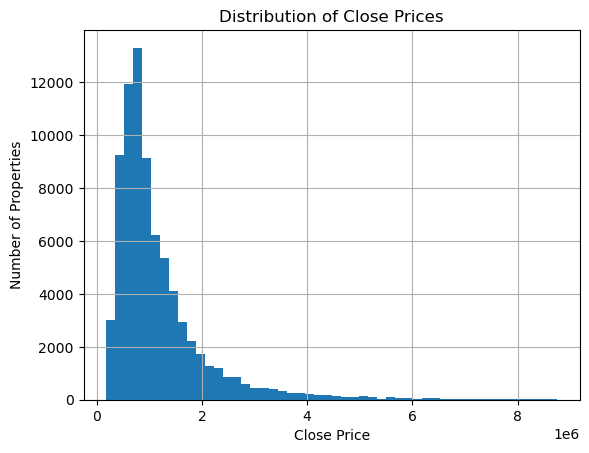

In [28]:
df_clean["ClosePrice"].hist(bins=50)

plt.title("Distribution of Close Prices")
plt.xlabel("Close Price")
plt.ylabel("Number of Properties")

Text(0, 0.5, 'Number of Properties')

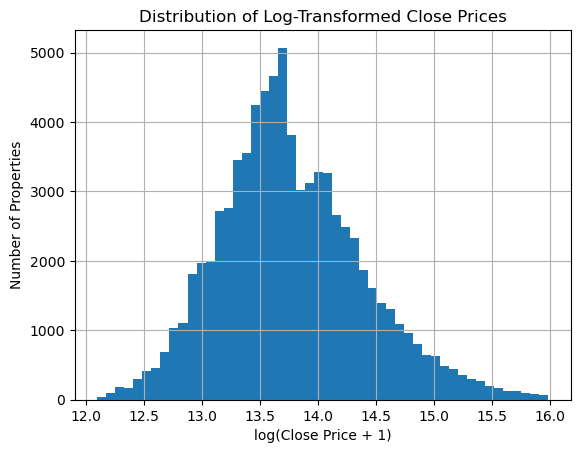

In [29]:
# Distribution of log-transformed close price
np.log1p(df_clean["ClosePrice"]).hist(bins=50)

plt.title("Distribution of Log-Transformed Close Prices")
plt.xlabel("log(Close Price + 1)")
plt.ylabel("Number of Properties")

Text(0, 0.5, 'Close Price')

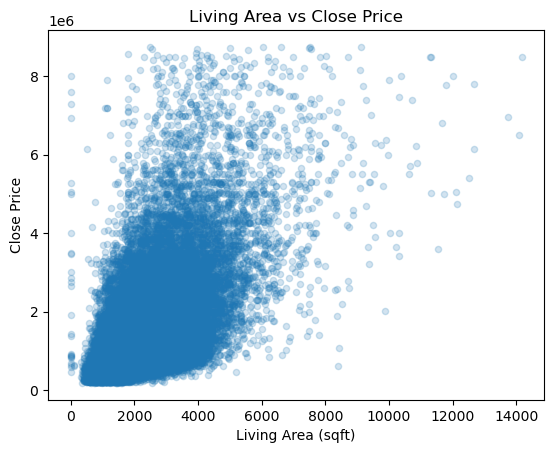

In [30]:
# Relationship between living area and close price
df_clean.plot.scatter(x="LivingArea", y="ClosePrice", alpha=0.2)

plt.title("Living Area vs Close Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Close Price")

Text(0, 0.5, 'Close Price')

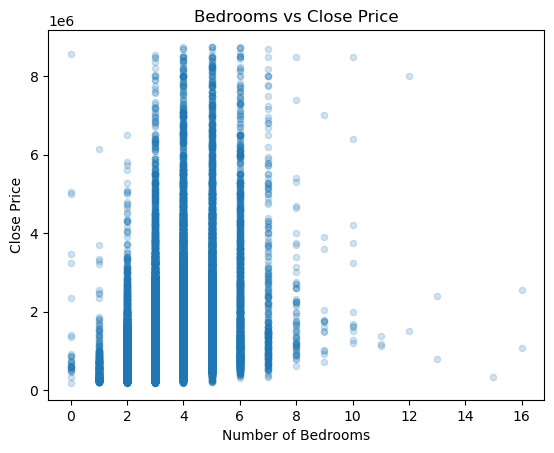

In [31]:
# Bedrooms vs close price
df_clean.plot.scatter(x="BedroomsTotal", y="ClosePrice", alpha=0.2)

plt.title("Bedrooms vs Close Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Close Price")

Text(0, 0.5, 'Close Price')

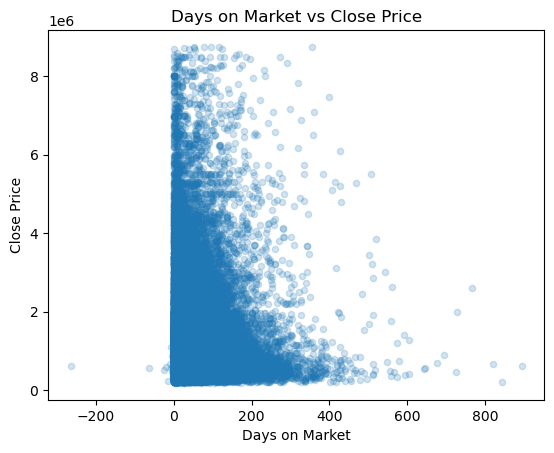

In [32]:
df_clean.plot.scatter(
    x="DaysOnMarket",
    y="ClosePrice",
    alpha=0.2
)

plt.title("Days on Market vs Close Price")
plt.xlabel("Days on Market")
plt.ylabel("Close Price")

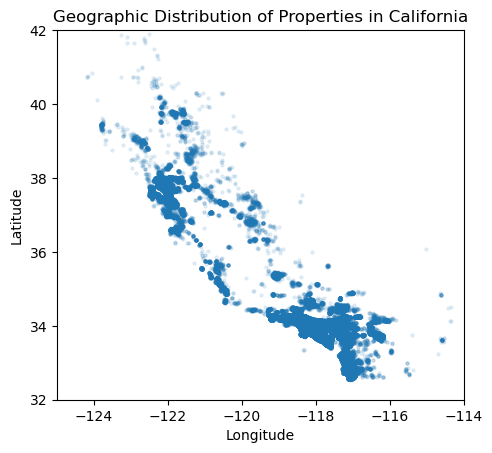

In [33]:
# Geographic distribution of properties (filtered to California bounds)

ca_mask = (
    (df_clean["Latitude"].between(32, 42)) &
    (df_clean["Longitude"].between(-125, -114))
)

plt.scatter(
    df_clean.loc[ca_mask, "Longitude"],
    df_clean.loc[ca_mask, "Latitude"],
    alpha=0.1,
    s=5
)

plt.title("Geographic Distribution of Properties in California")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-125, -114)
plt.ylim(32, 42)
plt.gca().set_aspect("equal", adjustable="box")

Text(0, 0.5, 'Close Price')

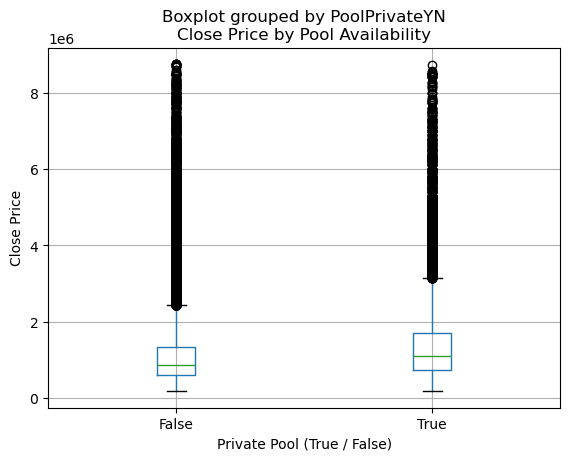

In [34]:
df_clean.boxplot(column="ClosePrice", by="PoolPrivateYN")

plt.title("Close Price by Pool Availability")
plt.xlabel("Private Pool (True / False)")
plt.ylabel("Close Price")

Text(0, 0.5, 'Close Price')

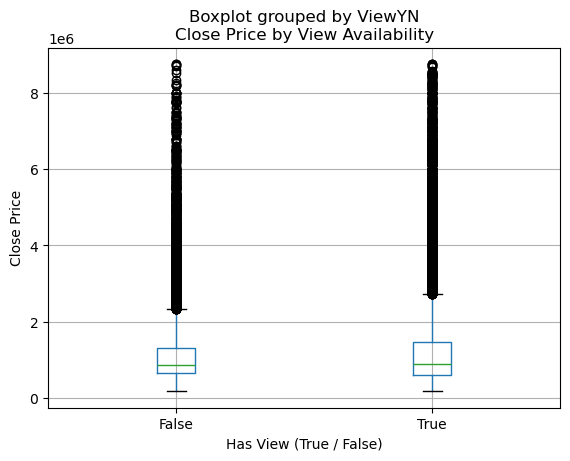

In [35]:
# Effect of having a view on close price
df_clean.boxplot(column="ClosePrice", by="ViewYN")

plt.title("Close Price by View Availability")
plt.xlabel("Has View (True / False)")
plt.ylabel("Close Price")

In [ ]:
df_temp = df_clean.copy()
df_temp["log_price"] = np.log1p(df_temp["ClosePrice"])

numeric_cols = df_temp.select_dtypes(include="number").columns
corr = df_temp[numeric_cols].corr()["log_price"].sort_values(ascending=False)

corr.head(15)

log_price                1.000000
LogClosePrice            1.000000
ClosePrice               0.896770
ListPrice                0.880789
LivingArea               0.570118
BathroomsTotalInteger    0.536494
BedroomsTotal            0.381931
Stories                  0.181838
AssociationFee           0.117106
OriginalListPrice        0.091859
GarageSpaces             0.060469
ListingKey               0.043320
ListingKeyNumeric        0.043320
ParkingTotal             0.029546
MainLevelBedrooms        0.024814
Name: log_price, dtype: float64

#### Data Preprocessing

In [ ]:
target_col = "ClosePrice"
split_col = "split"

core_numeric = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeAcres",
    "DaysOnMarket",
    "Latitude",
    "Longitude",
]

core_categorical = [
    "PostalCode",
    "City",
    "Levels",
    "ViewYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "NewConstructionYN",
]

core_numeric = [c for c in core_numeric if c in df_clean.columns]
core_categorical = [c for c in core_categorical if c in df_clean.columns]

keep_cols = [target_col, split_col] + core_numeric + core_categorical
df_model = df_clean[keep_cols].copy()

if "PostalCode" in df_model.columns:
    df_model["PostalCode"] = df_model["PostalCode"].astype(str)

print("df_model shape:", df_model.shape)
print("\nSplit counts:")
print(df_model[split_col].value_counts(dropna=False))

print("\nMissing target count:")
print(df_model[target_col].isna().sum())

print("\nColumns used:")
print(df_model.columns.tolist())

df_model shape: (78162, 16)

Split counts:
split
train    67812
test     10350
Name: count, dtype: int64

Missing target count:
0

Columns used:
['ClosePrice', 'split', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'DaysOnMarket', 'Latitude', 'Longitude', 'PostalCode', 'City', 'Levels', 'ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'NewConstructionYN']


In [ ]:
df_model["log_price"] = np.log1p(df_model["ClosePrice"])

train_df = df_model[df_model["split"] == "train"].copy()
test_df  = df_model[df_model["split"] == "test"].copy()

target = "log_price"

feature_cols = [c for c in df_model.columns if c not in ["ClosePrice", "log_price", "split"]]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test  = test_df[feature_cols]
y_test  = test_df[target]

print("Features used:", feature_cols)

Features used: ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'DaysOnMarket', 'Latitude', 'Longitude', 'PostalCode', 'City', 'Levels', 'ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'NewConstructionYN']


In [ ]:
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

#### Model 0: LinearRegression

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", linear_model)
])

linear_pipe.fit(X_train, y_train)

pred_log_lin = linear_pipe.predict(X_test)

mae_log_lin = mean_absolute_error(y_test, pred_log_lin)
rmse_log_lin = mean_squared_error(y_test, pred_log_lin, squared=False)
r2_log_lin = r2_score(y_test, pred_log_lin)

print("=== Linear Regression (Log space) ===")
print("MAE:", round(mae_log_lin, 4))
print("RMSE:", round(rmse_log_lin, 4))
print("R2:", round(r2_log_lin, 4))


pred_price_lin = np.expm1(pred_log_lin)
true_price = np.expm1(y_test)

mae_lin = mean_absolute_error(true_price, pred_price_lin)
rmse_lin = mean_squared_error(true_price, pred_price_lin, squared=False)
r2_lin = r2_score(true_price, pred_price_lin)

print("\n=== Linear Regression (Original Price) ===")
print("MAE:", round(mae_lin, 0))
print("RMSE:", round(rmse_lin, 0))
print("R2:", round(r2_lin, 4))

=== Linear Regression (Log space) ===
MAE: 0.1402
RMSE: 0.2044
R2: 0.8913

=== Linear Regression (Original Price) ===
MAE: 184158.0
RMSE: 431606.0
R2: 0.7845


c:\Users\yhy_s\miniforge3\envs\dsc80\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\yhy_s\miniforge3\envs\dsc80\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


#### 

In [49]:
feature_cols

['LivingArea',
 'BedroomsTotal',
 'BathroomsTotalInteger',
 'LotSizeAcres',
 'DaysOnMarket',
 'Latitude',
 'Longitude',
 'PostalCode',
 'City',
 'Levels',
 'ViewYN',
 'PoolPrivateYN',
 'AttachedGarageYN',
 'NewConstructionYN']

#### Model 1: Ridge

In [ ]:
ridge_model = Ridge(alpha=1.0, random_state=42)

ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ridge_model)
])

ridge_pipe.fit(X_train, y_train)

pred_log_ridge = ridge_pipe.predict(X_test)

mae_log_ridge = mean_absolute_error(y_test, pred_log_ridge)
rmse_log_ridge = mean_squared_error(y_test, pred_log_ridge, squared=False)
r2_log_ridge = r2_score(y_test, pred_log_ridge)

print("=== Ridge Regression (Log space) ===")
print("MAE:", round(mae_log_ridge, 4))
print("RMSE:", round(rmse_log_ridge, 4))
print("R2:", round(r2_log_ridge, 4))


pred_price_ridge = np.expm1(pred_log_ridge)
true_price = np.expm1(y_test)

mae_ridge = mean_absolute_error(true_price, pred_price_ridge)
rmse_ridge = mean_squared_error(true_price, pred_price_ridge, squared=False)
r2_ridge = r2_score(true_price, pred_price_ridge)

print("\n=== Ridge Regression (Original Price) ===")
print("MAE:", round(mae_ridge, 0))
print("RMSE:", round(rmse_ridge, 0))
print("R2:", round(r2_ridge, 4))

=== Ridge Regression (Log space) ===
MAE: 0.1401
RMSE: 0.2035
R2: 0.8923

=== Ridge Regression (Original Price) ===
MAE: 184251.0
RMSE: 431946.0
R2: 0.7842


c:\Users\yhy_s\miniforge3\envs\dsc80\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\yhy_s\miniforge3\envs\dsc80\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [51]:
for a in [0.01, 0.1, 1, 10, 100]:
    ridge = Ridge(alpha=a)
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", ridge)
    ])
    pipe.fit(X_train, y_train)
    r2 = r2_score(y_test, pipe.predict(X_test))
    print(f"alpha={a}, R2_log={round(r2,4)}")

alpha=0.01, R2_log=0.892
alpha=0.1, R2_log=0.8922
alpha=1, R2_log=0.8923
alpha=10, R2_log=0.8845
alpha=100, R2_log=0.8118
